# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [2]:
# Install if needed (uncomment the line below)
#!pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: C:\Users\delli\dsLab\projects\data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [5]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("span", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

""


Data saved to quotes.csv


In [2]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts

In [3]:

 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "}":
        depth -= 1
        if depth == 0:
            break
 

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [4]:

 
data = json.loads(html[start:end + 1])
print("JSON loaded successfully")
 
 
# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]
print("Number of listings found:", len(properties))
 
 
# ---------- STEP 4: pick the fields we want ----------
def price_in_lakh(rupees):
    """21998600 -> 220.0 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None
 
 
def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None
 
 
rows = []
for p in properties:
    # Some listings are a price RANGE (e.g. "2.25 - 3.28 Cr").
    # We keep the minimum price, and also record the text version.
    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })
 
houses = pd.DataFrame(rows)
 
# NOTE: this page also contains agent names and phone numbers.
# We deliberately do NOT collect those - that is personal data.
 
 
# ---------- STEP 5: quick check ----------
print("\nAll areas in sqft?", (houses["area_unit"] == "sqft").all())
print("Missing values:\n", houses.isna().sum().to_string())
 
 
# ---------- STEP 6: save ----------
houses.to_csv(OUTPUT_FILE, index=False)
print("\nSaved", len(houses), "rows to", OUTPUT_FILE)
print(houses.head(10).to_string(index=False))

JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4879.5      sqft      490.53 4.91  - 

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

In [10]:
from bs4 import BeautifulSoup
import csv
import re

html_file = "data/Magicbrick.html"
csv_file = "data/bengaluru_properties.csv"

with open(html_file, "r", encoding="utf-8") as file:
    html = file.read()

soup = BeautifulSoup(html, "html.parser")

properties = []

property_cards = soup.select(".mb-srp__card")

print("Property cards found:", len(property_cards))


def get_text(card, selectors):
    for selector in selectors:
        element = card.select_one(selector)
        if element:
            return element.get_text(" ", strip=True)
    return ""


for card in property_cards:

    title = get_text(card, [
        ".mb-srp__card--title"
    ])

    price = get_text(card, [
        ".mb-srp__card__price--amount"
    ])

    location = get_text(card, [
        ".mb-srp__card--location",
        ".mb-srp__card__location",
        ".mb-srp__card--address"
    ])

    description = get_text(card, [
        ".mb-srp__card--desc"
    ])

    bhk = ""
    area = ""

    summary_items = card.select(".mb-srp__card__summary__list")

    for item in summary_items:
        text = item.get_text(" ", strip=True)

        if re.search(r"\b(BHK|Bedroom|Bed)\b", text, re.I):
            bhk = text

        if re.search(r"(sqft|sq\.ft|sq ft|square feet)", text, re.I):
            area = text

    if not bhk or not area:
        summary_values = card.select(".mb-srp__card__summary--value")

        for value in summary_values:
            text = value.get_text(" ", strip=True)

            if not bhk and re.search(r"\b(BHK|Bedroom|Bed)\b", text, re.I):
                bhk = text

            if not area and re.search(r"(sqft|sq\.ft|sq ft|square feet)", text, re.I):
                area = text

    if not bhk:
        text = card.get_text(" ", strip=True)
        match = re.search(r"\b(\d+)\s*BHK\b", text, re.I)

        if match:
            bhk = match.group(0)

    if not area:
        text = card.get_text(" ", strip=True)
        match = re.search(
            r"[\d,]+(?:\.\d+)?\s*(?:sq\.?\s*ft|sqft|square feet)",
            text,
            re.I
        )

        if match:
            area = match.group(0)

    properties.append({
        "Title": title,
        "Price": price,
        "Location": location,
        "Area": area,
        "BHK": bhk,
        "Description": description
    })


fieldnames = [
    "Title",
    "Price",
    "Location",
    "Area",
    "BHK",
    "Description"
]

with open(csv_file, "w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(properties)

print("Data extracted successfully!")
print("Number of properties:", len(properties))
print("CSV saved as:", csv_file)

Property cards found: 30
Data extracted successfully!
Number of properties: 30
CSV saved as: data/bengaluru_properties.csv


### Result — Experiment 1

**Number of listings collected:** _30_

**Columns collected:** _6_

**File saved:** _data/bengaluru_properties.csv_

**Observation:**
30 property listings were successfully extracted from the MagicBricks HTML file using BeautifulSoup and stored in CSV format. The dataset contains 6 property-related attributes for further analysis.

> ...

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [13]:
import requests

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-17T15:15
  interval              : 900
  temperature_2m        : 30.3
  relative_humidity_2m  : 42
  wind_speed_10m        : 16.1


In [14]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-17 00:00:00,21.9,81,0.0
1,2026-08-17 01:00:00,21.3,85,0.0
2,2026-08-17 02:00:00,20.7,88,0.0
3,2026-08-17 03:00:00,20.3,91,0.0
4,2026-08-17 04:00:00,20.1,92,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [17]:
import requests
import pandas as pd
import time

URL = "https://api.open-meteo.com/v1/forecast"

# #1 - Collect weather data for Mysuru

params_mysuru = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

response = requests.get(URL, params=params_mysuru, timeout=20)

print("Status code:", response.status_code)

weather_mysuru = response.json()

wx_mysuru = pd.DataFrame(weather_mysuru["hourly"])

wx_mysuru["time"] = pd.to_datetime(wx_mysuru["time"])

# Save the data as CSV
wx_mysuru.to_csv("weather_mysuru.csv", index=False)

print("Mysuru weather data saved to weather_mysuru.csv")
print(wx_mysuru.head())
print("Number of records:", len(wx_mysuru))


# #2 - Add wind_speed_10m to the hourly parameters

params_mysuru_wind = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

print("\nComplete parameter configuration:")
print(params_mysuru_wind)

response = requests.get(URL, params=params_mysuru_wind, timeout=20)

print("Status code:", response.status_code)

weather_mysuru_wind = response.json()

wx_mysuru_wind = pd.DataFrame(weather_mysuru_wind["hourly"])

wx_mysuru_wind["time"] = pd.to_datetime(wx_mysuru_wind["time"])

print("\nColumns in the output:")
print(wx_mysuru_wind.columns.tolist())

print("\nFirst five records:")
print(wx_mysuru_wind.head())

# Confirm wind_speed_10m exists
if "wind_speed_10m" in wx_mysuru_wind.columns:
    print("\nwind_speed_10m successfully added to the output.")
else:
    print("\nwind_speed_10m was not found.")


# #3 - Test an invalid latitude

bad_params = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

response_bad = requests.get(URL, params=bad_params, timeout=20)

print("\nStatus code for invalid latitude:", response_bad.status_code)

# Expected result:
# 400 = Bad Request

# #4 - Collect weather data for 3 cities using a for loop

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru": (12.2958, 76.6394),
    "Chennai": (13.0827, 80.2707)
}

all_weather_data = []

for city, coordinates in cities.items():

    latitude, longitude = coordinates

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "forecast_days": 7
    }

    response = requests.get(URL, params=params, timeout=20)

    print(city, "- Status code:", response.status_code)

    data = response.json()

    city_weather = pd.DataFrame(data["hourly"])

    city_weather["time"] = pd.to_datetime(city_weather["time"])

    # Add city name so that the three datasets can be distinguished
    city_weather["city"] = city

    all_weather_data.append(city_weather)

    # Wait before making the next API request
    time.sleep(1)


# Combine all three city DataFrames
combined_weather = pd.concat(
    all_weather_data,
    ignore_index=True
)

print("\nCombined DataFrame:")
print(combined_weather.head())

print("\nDataFrame shape:")
print(combined_weather.shape)

print("\nCities represented:")
print(combined_weather["city"].unique())

print("\nNumber of records for each city:")
print(combined_weather["city"].value_counts())

Status code: 200
Mysuru weather data saved to weather_mysuru.csv
                 time  temperature_2m  relative_humidity_2m  precipitation
0 2026-08-17 00:00:00            21.2                    91            0.0
1 2026-08-17 01:00:00            21.0                    92            0.0
2 2026-08-17 02:00:00            20.8                    93            0.0
3 2026-08-17 03:00:00            20.8                    93            0.0
4 2026-08-17 04:00:00            21.0                    92            0.0
Number of records: 168

Complete parameter configuration:
{'latitude': 12.2958, 'longitude': 76.6394, 'hourly': 'temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m', 'timezone': 'Asia/Kolkata', 'forecast_days': 7}
Status code: 200

Columns in the output:
['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']

First five records:
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2026-08-17 00:00:00          

### Result — Experiment 2

**API used:** _"https://api.open-meteo.com/v1/forecast"_

**Number of records collected:** _168_

**Columns collected:** _time, temperature_2m, relative_humidity_2m, precipitation_

**File saved:** _weather_mysuru.csv_

**Observation:**
Weather data for Mysuru was successfully collected from the Open-Meteo REST API for 7 days, resulting in 168 hourly records. The data contains time, temperature, relative humidity, and precipitation values and was successfully saved as `weather_mysuru.csv`.
> ...

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [18]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data\air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-10 00:00:00,7.1,8.9,11.5,35.0
1,2026-08-10 01:00:00,6.0,7.6,9.6,34.0
2,2026-08-10 02:00:00,5.1,6.7,8.1,33.0
3,2026-08-10 03:00:00,4.5,6.2,7.0,32.0
4,2026-08-10 04:00:00,4.0,5.8,6.2,31.0


Average PM2.5: 7.2 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


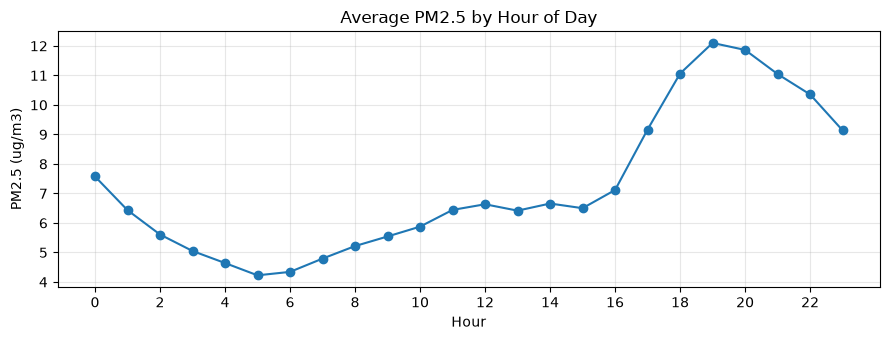

In [21]:
# --- Check what we collected ---
import matplotlib.pyplot as plt

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [22]:
# 1. Collect air quality data for Delhi and compare average PM2.5

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params_delhi = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

r_delhi = requests.get(AQ_URL, params=params_delhi, timeout=20)

print("Delhi status code:", r_delhi.status_code)

delhi_data = r_delhi.json()

delhi_aq = pd.DataFrame(delhi_data["hourly"])

delhi_aq["time"] = pd.to_datetime(delhi_aq["time"])

delhi_avg_pm25 = delhi_aq["pm2_5"].mean()
bengaluru_avg_pm25 = aq["pm2_5"].mean()

print("Average Delhi PM2.5:", round(delhi_avg_pm25, 2), "ug/m3")
print("Average Bengaluru PM2.5:", round(bengaluru_avg_pm25, 2), "ug/m3")

if delhi_avg_pm25 > bengaluru_avg_pm25:
    print("Delhi is more polluted based on average PM2.5.")
else:
    print("Bengaluru is more polluted based on average PM2.5.")


# 2. Increase past_days from 7 to 30

params_delhi_30 = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 30
}

r_delhi_30 = requests.get(AQ_URL, params=params_delhi_30, timeout=20)

delhi_30_data = r_delhi_30.json()

delhi_aq_30 = pd.DataFrame(delhi_30_data["hourly"])

print("Number of rows:", len(delhi_aq_30))


# 3. Add sulphur_dioxide and carbon_monoxide

params_delhi_pollutants = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "timezone": "Asia/Kolkata",
    "past_days": 30
}

r_pollutants = requests.get(
    AQ_URL,
    params=params_delhi_pollutants,
    timeout=20
)

pollutant_data = r_pollutants.json()

delhi_pollution = pd.DataFrame(pollutant_data["hourly"])

delhi_pollution["time"] = pd.to_datetime(delhi_pollution["time"])

print("Columns collected:")
print(delhi_pollution.columns.tolist())

print("\nFirst five rows:")
print(delhi_pollution.head())

Delhi status code: 200
Average Delhi PM2.5: 61.71 ug/m3
Average Bengaluru PM2.5: 7.16 ug/m3
Delhi is more polluted based on average PM2.5.
Number of rows: 840
Columns collected:
['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']

First five rows:
                 time  pm2_5   pm10  nitrogen_dioxide  ozone  sulphur_dioxide  \
0 2026-07-18 00:00:00  197.9  722.7              84.2    0.0             33.1   
1 2026-07-18 01:00:00  191.4  646.3              81.2    0.0             32.9   
2 2026-07-18 02:00:00  176.0  538.3              76.6    1.0             31.9   
3 2026-07-18 03:00:00  155.1  434.0              70.9    3.0             30.0   
4 2026-07-18 04:00:00  131.3  349.2              63.6    7.0             27.2   

   carbon_monoxide  
0            714.0  
1            561.0  
2            435.0  
3            341.0  
4            273.0  


## Result — Experiment 3

**API used:** _"https://air-quality-api.open-meteo.com/v1/air-quality"_

**Pollutants collected:** _pm2_5, pm10, nitrogen_dioxide, ozone, sulphur_dioxide, carbon_monoxide_

**Number of records:** _288_

**Observation:**
Air quality data for Bengaluru was successfully collected using the Open-Meteo Air Quality API. A total of 288 hourly records were obtained for 7 days. The dataset contains PM2.5, PM10, nitrogen dioxide, ozone, sulphur dioxide, and carbon monoxide measurements for further analysis.


# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200
Weather status: 200
Air quality status: 200

Dataset shape:
(8400, 14)

Records for each location:
location
Connaught Place    840
Rohini             840
Dwarka             840
Saket              840
Lajpat Nagar       840
Karol Bagh         840
Anand Vihar        840
Vasant Kunj        840
Noida              840
Delhi Airport      840
Name: count, dtype: int64

Missing values before cleaning:
location             0
latitude             0
longitude            0
time                 0
temperature          0
humidity             0
precipitation        0
wind_speed           0
pm2_5               60


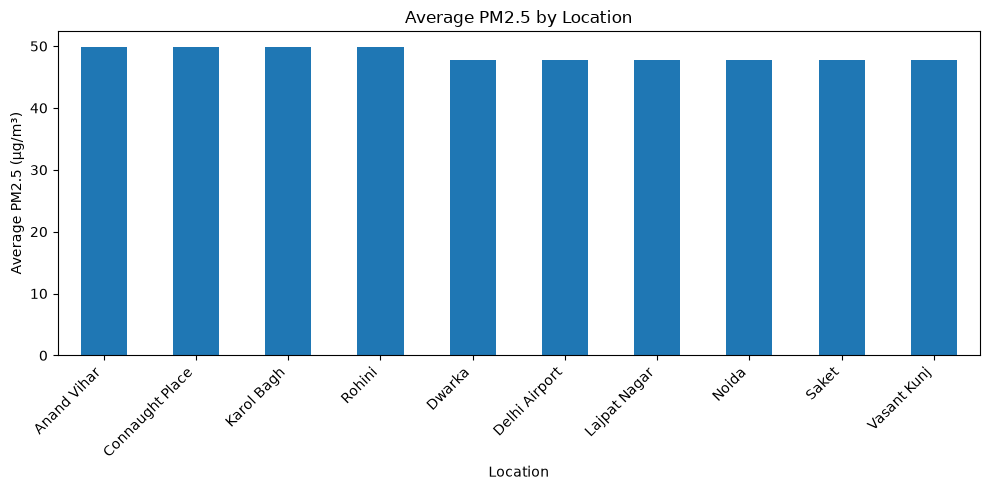


Correlation with PM2.5:
pm2_5            1.000000
humidity         0.103044
temperature     -0.018118
precipitation   -0.112925
wind_speed      -0.311093
Name: pm2_5, dtype: float64


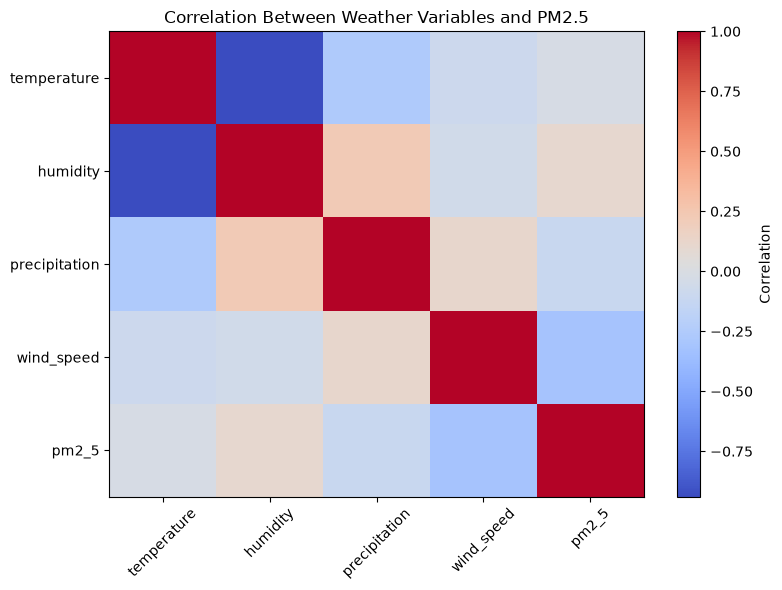

In [2]:
# ============================================================
# Creating a Large Air Quality & Weather Dataset
# ============================================================

import requests
import pandas as pd
import time


# ============================================================
# API URLs
# ============================================================

WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"


# ============================================================
# 10 Locations in and around Delhi
# Coordinates: latitude, longitude
# ============================================================

locations = {
    "Connaught Place": (28.6315, 77.2167),
    "Rohini": (28.7495, 77.0565),
    "Dwarka": (28.5921, 77.0460),
    "Saket": (28.5245, 77.2066),
    "Lajpat Nagar": (28.5677, 77.2433),
    "Karol Bagh": (28.6514, 77.1907),
    "Anand Vihar": (28.6469, 77.3160),
    "Vasant Kunj": (28.5206, 77.1566),
    "Noida": (28.5355, 77.3910),
    "Delhi Airport": (28.5562, 77.1000)
}


# ============================================================
# Lists to store data
# ============================================================

all_data = []


# ============================================================
# Collect data for all 10 locations
# ============================================================

for location, (latitude, longitude) in locations.items():

    print("Collecting data for:", location)

    # --------------------------------------------------------
    # Weather API
    # --------------------------------------------------------

    weather_params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "past_days": 30
    }

    weather_response = requests.get(
        WEATHER_URL,
        params=weather_params,
        timeout=20
    )

    print("Weather status:", weather_response.status_code)

    weather_data = weather_response.json()

    weather_df = pd.DataFrame(weather_data["hourly"])

    weather_df["time"] = pd.to_datetime(weather_df["time"])


    # --------------------------------------------------------
    # Air Quality API
    # --------------------------------------------------------

    aq_params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": (
            "pm2_5,pm10,nitrogen_dioxide,ozone,"
            "sulphur_dioxide,carbon_monoxide"
        ),
        "timezone": "Asia/Kolkata",
        "past_days": 30
    }

    aq_response = requests.get(
        AQ_URL,
        params=aq_params,
        timeout=20
    )

    print("Air quality status:", aq_response.status_code)

    aq_data = aq_response.json()

    aq_df = pd.DataFrame(aq_data["hourly"])

    aq_df["time"] = pd.to_datetime(aq_df["time"])


    # --------------------------------------------------------
    # Merge weather and air-quality data using time
    # --------------------------------------------------------

    df = pd.merge(
        weather_df,
        aq_df,
        on="time",
        how="inner"
    )


    # --------------------------------------------------------
    # Add location information
    # --------------------------------------------------------

    df["location"] = location
    df["latitude"] = latitude
    df["longitude"] = longitude


    # --------------------------------------------------------
    # Rename weather columns
    # --------------------------------------------------------

    df = df.rename(columns={
        "temperature_2m": "temperature",
        "relative_humidity_2m": "humidity",
        "wind_speed_10m": "wind_speed"
    })


    # Store this location's data
    all_data.append(df)


    # --------------------------------------------------------
    # Wait before the next API requests
    # --------------------------------------------------------

    time.sleep(1)


# ============================================================
# Combine all 10 locations
# ============================================================

final_df = pd.concat(
    all_data,
    ignore_index=True
)


# ============================================================
# Arrange columns in the required order
# ============================================================

final_df = final_df[
    [
        "location",
        "latitude",
        "longitude",
        "time",
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5",
        "pm10",
        "nitrogen_dioxide",
        "ozone",
        "sulphur_dioxide",
        "carbon_monoxide"
    ]
]


# ============================================================
# Check dataset size
# ============================================================

print("\nDataset shape:")
print(final_df.shape)

print("\nRecords for each location:")
print(final_df["location"].value_counts())


# ============================================================
# Check for missing values
# ============================================================

print("\nMissing values before cleaning:")
print(final_df.isnull().sum())


# ============================================================
# Check for invalid/non-numeric values
# ============================================================

numeric_columns = [
    "latitude",
    "longitude",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "ozone",
    "sulphur_dioxide",
    "carbon_monoxide"
]

final_df[numeric_columns] = final_df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)


# ============================================================
# Handle missing values
# ============================================================

# Interpolate values within each location
final_df[numeric_columns] = (
    final_df
    .groupby("location")[numeric_columns]
    .transform(lambda x: x.interpolate())
)

# Fill any missing values remaining at the beginning/end
final_df[numeric_columns] = (
    final_df
    .groupby("location")[numeric_columns]
    .transform(lambda x: x.ffill().bfill())
)


# ============================================================
# Check missing values after cleaning
# ============================================================

print("\nMissing values after cleaning:")
print(final_df.isnull().sum())


# ============================================================
# Save final dataset
# ============================================================

final_df.to_csv(
    "delhi_air_quality_weather_30days.csv",
    index=False
)

print("\nFinal dataset saved as:")
print("delhi_air_quality_weather_30days.csv")


# ============================================================
# ANALYSIS
# Which location has the highest average PM2.5?
# ============================================================

average_pm25 = (
    final_df
    .groupby("location")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage PM2.5 by location:")
print(average_pm25)


highest_location = average_pm25.idxmax()
highest_pm25 = average_pm25.max()

print("\nLocation with highest average PM2.5:")
print(highest_location)

print("Average PM2.5:", round(highest_pm25, 2), "µg/m³")

import matplotlib.pyplot as plt
average_pm25 = (
    final_df.groupby("location")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

average_pm25.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average PM2.5 by Location"
)

plt.xlabel("Location")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ============================================================
# WEATHER VS PM2.5 CORRELATION
# ============================================================

weather_pm25 = final_df[
    [
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5"
    ]
].corr()["pm2_5"].sort_values(ascending=False)

print("\nCorrelation with PM2.5:")
print(weather_pm25)

import matplotlib.pyplot as plt

corr = final_df[
    [
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5"
    ]
].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar(label="Correlation")
plt.title("Correlation Between Weather Variables and PM2.5")

plt.tight_layout()
plt.show()

In [9]:
from pathlib import Path

# --- Final check: list all files and folders collected ---

DATA = Path(".")

print("Files collected in this lab:\n")

for item in sorted(DATA.iterdir()):

    if item.is_dir():
        print(f"📁 {item.name}/")

        for file in sorted(item.rglob("*")):
            if file.is_file():
                relative = file.relative_to(item)
                print(f"   └── {relative} ({file.stat().st_size:,} bytes)")

    else:
        print(f"📄 {item.name} ({item.stat().st_size:,} bytes)")

Files collected in this lab:

📁 .ipynb_checkpoints/
   └── bengaluru_houses-checkpoint.csv (2,446 bytes)
   └── delhi_air_quality_weather_30days-checkpoint.csv (794,379 bytes)
   └── Lab_Data_Collection_Simple-checkpoint.ipynb (75,631 bytes)
📄 bengaluru_houses.csv (2,446 bytes)
📁 data/
   └── .ipynb_checkpoints\bengaluru_properties-checkpoint.csv (22,029 bytes)
   └── .ipynb_checkpoints\House-checkpoint.html (1,774,801 bytes)
   └── .ipynb_checkpoints\weather_mysuru-checkpoint.csv (6,449 bytes)
   └── air_quality.csv (11,220 bytes)
   └── bengaluru_properties.csv (22,883 bytes)
   └── House.html (1,774,801 bytes)
   └── Magicbrick.html (1,502,328 bytes)
   └── Magicbrick_files\.ipynb_checkpoints\34d585d5-2ca8-4f29-8724-07fac03f931f_85985139_180_240-checkpoint.jpg (2,893 bytes)
   └── Magicbrick_files\.ipynb_checkpoints\5725042_5725042_Logo_75_75-checkpoint.jpg (2,000 bytes)
   └── Magicbrick_files\26607941_WhatsAppImage20240329at125045PM_75_75.jpeg (1,946 bytes)
   └── Magicbrick_files

---
## Viva Questions

1. What is web scraping?
2. What is the difference between web scraping and using an API?
3. What is `robots.txt` and why should you check it?
4. What does BeautifulSoup do?
5. What is the difference between `find()` and `find_all()`?
6. What is JSON? How is it related to a Python dictionary?
7. What does status code 200 mean? What does 404 mean?
8. What is a query parameter in an API call?
9. Why should you wait a few seconds between requests?
10. Why is using an API better than scraping the same website?
11. What does `pd.read_html()` do?
12. Why do we save the collected data as a CSV file?


1. Web scraping is the process of automatically extracting data from websites using a program.

2. Web scraping extracts data from webpages, while an API provides data directly in a structured format.

3. `robots.txt` tells automated programs which parts of a website they are allowed to access. We check it to follow the website's rules.

4. BeautifulSoup parses HTML and helps us find and extract information from webpages.

5. `find()` returns the first matching element, while `find_all()` returns all matching elements.

6. JSON is a format for storing and exchanging structured data. JSON objects are similar to Python dictionaries because both use key-value pairs.

7. **200** means the request was successful. **404** means the requested resource was not found.

8. A query parameter is an additional value sent with an API request to specify what data we want, such as latitude or longitude.

9. To avoid overloading the server, respect API rate limits, and make requests responsibly.

10. An API usually provides structured and reliable data directly, making it easier to process than scraping webpages.

11. `pd.read_html()` extracts HTML tables from a webpage and converts them into Pandas DataFrames.

12. We save data as CSV because it is simple, portable, easy to share, and can be opened or analyzed using tools like Pandas and Excel.



## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.

